In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("../../datasets/student_outliers.csv")

<Axes: >

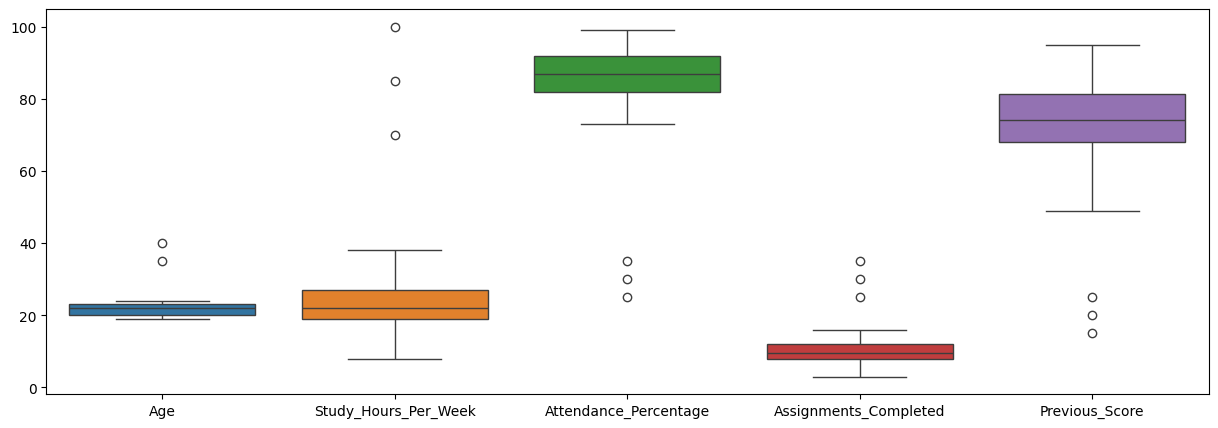

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
sns.boxplot(df)

In [5]:
df.describe()

,Age,Study_Hours_Per_Week,Attendance_Percentage,Assignments_Completed,Previous_Score
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,22.010000,24.300000,85.650000,10.120000,72.570000
std,2.776143,12.213174,11.669156,4.740285,13.852947
min,19.000000,8.000000,25.000000,3.000000,15.000000
25%,20.000000,19.000000,82.000000,8.000000,68.000000
50%,22.000000,22.000000,87.000000,9.500000,74.000000
75%,23.000000,27.000000,92.000000,12.000000,81.250000
max,40.000000,100.000000,99.000000,35.000000,95.000000


In [6]:
q1=df["Study_Hours_Per_Week"].quantile(0.25)
q3=df["Study_Hours_Per_Week"].quantile(0.75)

iqr=q3-q1

x= 1.5*iqr

lower=q1-x
upper=q3+x

print(f"Lower bound:{lower}\nUpper bound:{upper}")

Lower bound:7.0
Upper bound:39.0


In [7]:
outliers=df[
    (df["Study_Hours_Per_Week"]<lower)|
    (df["Study_Hours_Per_Week"]>upper)
]

outliers

,Student_ID,Age,Gender,Study_Hours_Per_Week,Attendance_Percentage,Assignments_Completed,Previous_Score,Internet_Access,Part_Time_Job,Performance
5,STU006,20,F,70,80,14,78,Yes,No,Excellent
25,STU026,23,F,85,81,12,77,No,No,Excellent
75,STU076,23,M,100,82,11,49,Yes,No,Excellent


In [8]:
df.head()

,Student_ID,Age,Gender,Study_Hours_Per_Week,Attendance_Percentage,Assignments_Completed,Previous_Score,Internet_Access,Part_Time_Job,Performance
0,STU001,22,M,25,84,10,78,Yes,Yes,Pass
1,STU002,23,F,27,85,4,74,Yes,Yes,Pass
2,STU003,21,M,27,76,12,57,Yes,No,Pass
3,STU004,23,M,27,94,13,64,Yes,No,Pass
4,STU005,23,M,21,95,10,69,Yes,No,Pass


In [9]:
x=df.drop(columns=["Performance","Student_ID"])
y=df["Performance"]

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,random_state=32,test_size=0.2)


In [11]:
x.head()
print(df["Internet_Access"].value_counts())
print(df["Part_Time_Job"].value_counts())

Internet_Access
Yes    86
No     14
Name: count, dtype: int64
Part_Time_Job
No     62
Yes    38
Name: count, dtype: int64


In [12]:


numeric_columns=[
    "Age",
    "Study_Hours_Per_Week",
    "Attendance_Percentage",
    "Assignments_Completed",
    "Previous_Score"
]

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,RobustScaler

preprocessor=ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(categories=[["No","Yes"],["No","Yes"],["M","F"]]),
            ["Internet_Access","Part_Time_Job","Gender"]
        ),
        (
            "numeric",
            RobustScaler(),
            numeric_columns
        )
    ],remainder='passthrough'
).set_output(transform='pandas')

In [14]:
X_train_trans=preprocessor.fit_transform(X_train)
X_test_trans=preprocessor.transform(X_test)
X_train_trans

,cat__Internet_Access,cat__Part_Time_Job,cat__Gender,numeric__Age,numeric__Study_Hours_Per_Week,numeric__Attendance_Percentage,numeric__Assignments_Completed,numeric__Previous_Score
26,0.0,0.0,0.0,0.000000,0.5625,0.526316,-0.3,0.377358
8,0.0,1.0,1.0,-0.333333,-0.1875,0.105263,-0.5,0.301887
7,1.0,1.0,1.0,-0.333333,0.8125,0.842105,1.1,0.754717
12,1.0,0.0,0.0,0.666667,0.5625,0.631579,-0.1,-0.452830
59,1.0,1.0,0.0,0.000000,-0.8125,-0.526316,0.1,1.207547
...,...,...,...,...,...,...,...,...
62,0.0,0.0,0.0,-0.333333,-0.5625,-0.105263,-0.5,0.754717
54,1.0,0.0,0.0,-0.666667,-0.8125,0.526316,-0.5,-0.754717
5,1.0,0.0,1.0,-0.666667,5.9375,-0.736842,0.9,0.301887
43,1.0,0.0,1.0,-0.333333,-0.3125,-0.315789,-0.3,-0.150943


<Axes: >

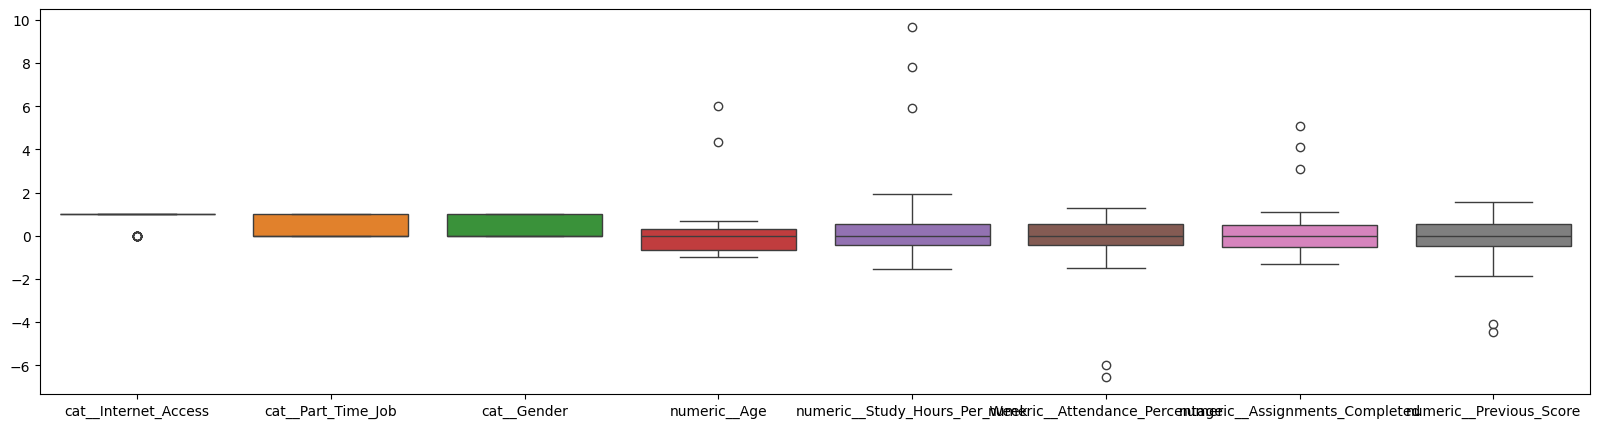

In [15]:
plt.figure(figsize=(20,5))
sns.boxplot(X_train_trans)

In [ ]:
from sklearn.